# Image Compression Using Singular Value Decomposition
---
Singular value decomposition (SVD) is an algorithm used to approximate and compress data in large matrices. While it can be used to condense large data sets, its most applicable use is for image compression.

Full SVD:  $ A = U \Sigma V^T $ </br>
Condensed SVD: $ A = \hat{U} \hat{\Sigma} \hat{V^T}$



In [ ]:
%matplotlib inline
import cv2 # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt
import numpy as np

# define the image that is being processed
img = 'flowers.jpeg'
img_data = cv2.imread(img)

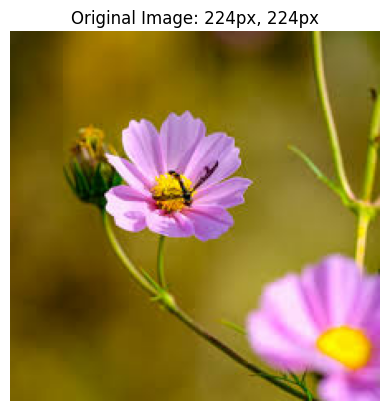

In [81]:
# Return the current image
def show_image(image, title:str):
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

res = img_data.shape
show_image(img_data, f"Original Image: {res[0]}px, {res[1]}px")

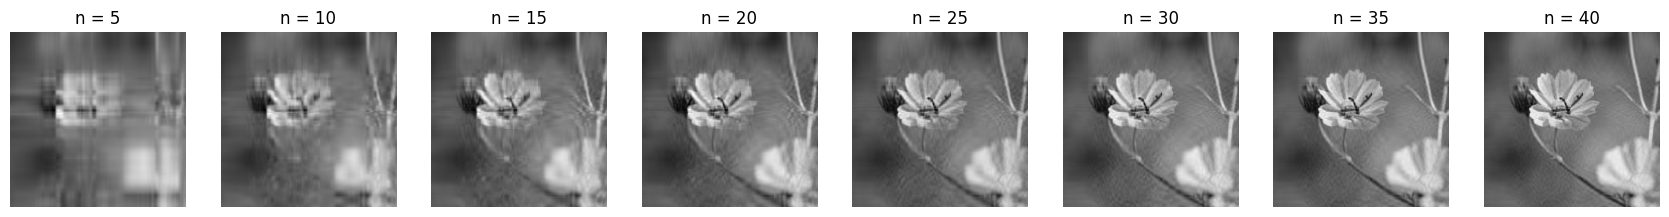

In [ ]:
# for grayscale images / output
def svd_gs(image, sv):
    img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
    U, S, Vt = np.linalg.svd(img, full_matrices=False)
    gs_img = np.matrix(U[:,:sv]) * np.diag(S[:sv]) * np.matrix(Vt[:sv,:])
    return gs_img

# showing the effect after adding 5 more singular values each frame
plt.figure(figsize=(24,4))
start, end, step = 5, 45, 5

for i in range(start, end, step):
    plt.subplot(1, (end - start) // step + 1, (i - start) // step + 1)
    img_gs = svd_gs(img, i) # does the svd compression
    plt.imshow(img_gs, cmap='grey')
    plt.title('n = %s' % i)
    plt.axis('off')

plt.show()

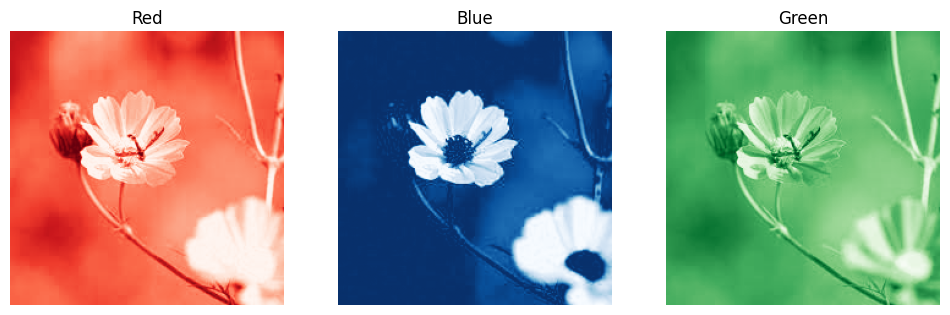

In [ ]:
B, G, R = cv2.split(img_data) # splitting color channels

colors = ['Red', 'Blue', 'Green']
matrices = [R, B, G]

plt.figure(figsize=(12, 4))
for i in range(len((colors))):
    plt.subplot(1, 3, i+1)
    plt.title(colors[i])
    plt.imshow(matrices[i],cmap=f'{colors[i]}s_r')
    plt.axis('off')
plt.show()

In [63]:
# Getting the singular values of the matrix S

sing_val_ex = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
U, S, Vt = np.linalg.svd(sing_val_ex, full_matrices=False)

np.set_printoptions(precision=1)  # 3 decimal places
print("Singular values of the image")
print(S)

Singular values of the image
[2.7e+04 5.2e+03 2.9e+03 1.9e+03 1.6e+03 1.6e+03 1.1e+03 1.1e+03 1.0e+03
 9.8e+02 8.7e+02 8.6e+02 7.4e+02 7.2e+02 7.0e+02 6.3e+02 6.1e+02 5.9e+02
 5.3e+02 5.2e+02 5.0e+02 4.7e+02 4.5e+02 4.4e+02 4.2e+02 4.0e+02 3.9e+02
 3.7e+02 3.6e+02 3.6e+02 3.3e+02 3.3e+02 3.2e+02 3.1e+02 3.0e+02 2.9e+02
 2.9e+02 2.8e+02 2.7e+02 2.6e+02 2.5e+02 2.4e+02 2.4e+02 2.3e+02 2.2e+02
 2.2e+02 2.0e+02 2.0e+02 1.9e+02 1.9e+02 1.8e+02 1.8e+02 1.7e+02 1.7e+02
 1.6e+02 1.6e+02 1.5e+02 1.5e+02 1.4e+02 1.4e+02 1.4e+02 1.3e+02 1.3e+02
 1.3e+02 1.2e+02 1.2e+02 1.1e+02 1.1e+02 1.1e+02 1.0e+02 1.0e+02 9.8e+01
 9.6e+01 9.2e+01 9.1e+01 8.6e+01 8.4e+01 8.3e+01 8.1e+01 7.5e+01 7.4e+01
 7.2e+01 7.1e+01 6.9e+01 6.7e+01 6.5e+01 6.2e+01 6.0e+01 5.8e+01 5.7e+01
 5.4e+01 5.3e+01 5.2e+01 5.1e+01 4.9e+01 4.7e+01 4.6e+01 4.4e+01 4.4e+01
 4.3e+01 4.2e+01 3.9e+01 3.8e+01 3.7e+01 3.5e+01 3.4e+01 3.3e+01 3.2e+01
 3.1e+01 3.0e+01 2.9e+01 2.8e+01 2.7e+01 2.6e+01 2.5e+01 2.5e+01 2.3e+01
 2.2e+01 2.2e+01 2.1e+

In [ ]:
%%time
U, S, Vt = np.linalg.svd(sing_val_ex, full_matrices=False)

CPU times: user 1.38 s, sys: 2.91 ms, total: 1.38 s
Wall time: 107 ms


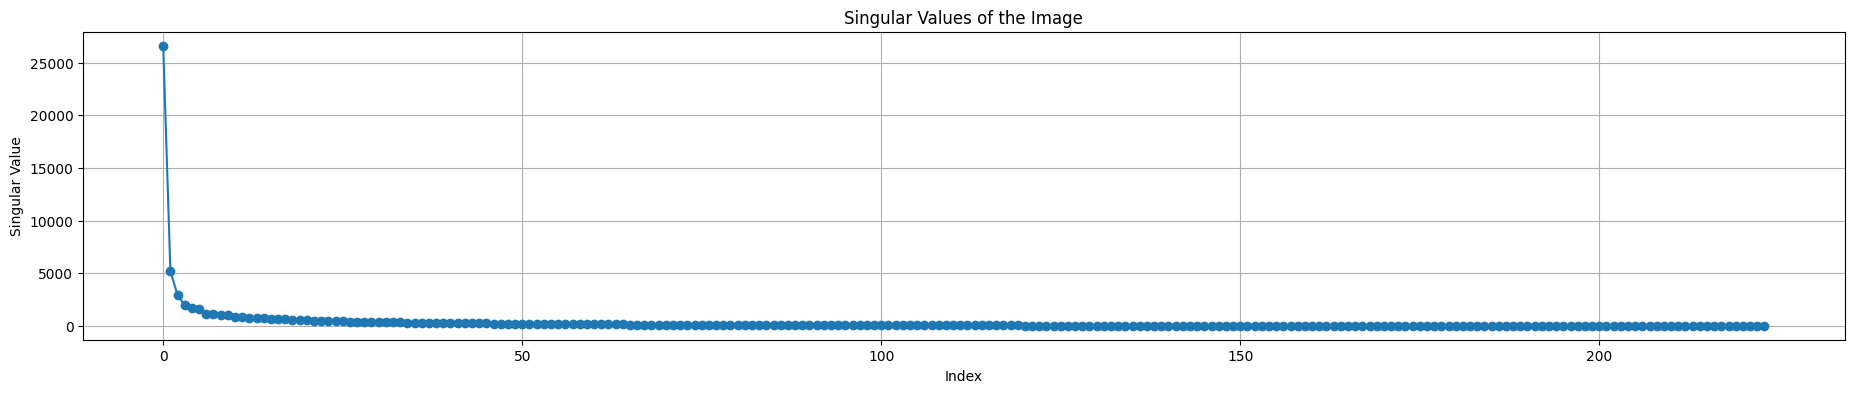

In [92]:
plt.figure(figsize=(50,4))
plt.subplot(1, 2, 1)
plt.plot(S, marker='o')
plt.title("Singular Values of the Image")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid(True)

# plt.subplot(1,2,2)
# plt.plot(S[:10], marker='o', color='orange')
# plt.title("First 10 Singular Values")
# plt.xlabel("Index")
# plt.ylabel("Singular Value")
# plt.grid(True)

plt.show()

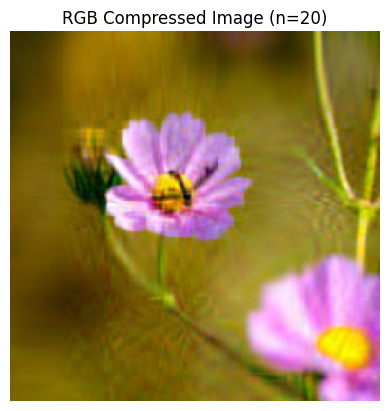

CPU times: user 10.8 s, sys: 12.8 ms, total: 10.8 s
Wall time: 782 ms


In [103]:
%%time
def svd_color(image, sv):
    B, G, R = cv2.split(image)

    U_b, S_b, Vt_b = np.linalg.svd(B, full_matrices=False)
    U_g, S_g, Vt_g = np.linalg.svd(G, full_matrices=False)
    U_r, S_r, Vt_r = np.linalg.svd(R, full_matrices=False)

    R_comp = np.matrix(U_r[:, :sv]) * np.diag(S_r[:sv]) * np.matrix(Vt_r[:sv, :])
    G_comp = np.matrix(U_g[:, :sv]) * np.diag(S_g[:sv]) * np.matrix(Vt_g[:sv, :])
    B_comp = np.matrix(U_b[:, :sv]) * np.diag(S_b[:sv]) * np.matrix(Vt_b[:sv, :])

    comp_full = cv2.merge([np.clip(R_comp, 1, 255), np.clip(G_comp, 1, 255), np.clip(B_comp, 1, 255)])
    comp_full = comp_full.astype(np.uint8)

    plt.imshow(comp_full)
    plt.title(f'RGB Compressed Image (n={sv})')
    plt.axis('off')
    plt.show()

svd_color(img_data, 20)